错误：无法读取图片，请检查路径


error: OpenCV(4.12.0) C:\miniconda3\conda-bld\opencv-suite_1761814921704\work\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


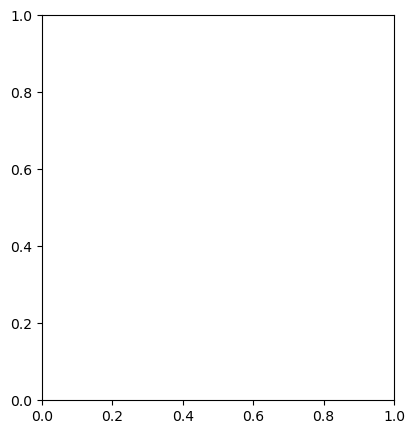

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_liquid_bridge(image_path):
    # 1. 读取图片
    # OpenCV 默认读取为 BGR 格式的彩色图像
    img = cv2.imread(image_path)
    if img is None:
        print("错误：无法读取图片，请检查路径")
        return

    # 2. 转换为灰度图
    # 颜色空间从 BGR 转换到灰度，简化处理
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. 高斯模糊 (去噪)
    # 液桥边缘可能存在噪点，高斯模糊可以平滑图像，使边缘检测更准确
    # (5,5) 是核大小，0 表示标准差由内核大小自动计算
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 4. 二值化 (otsu 方法)
    # Otsu's 方法会自动计算一个最佳阈值，将图像分为前景(液桥)和背景
    # 由于液桥通常是较亮的反射区域，背景较暗，我们使用 THRESH_BINARY_INV
    # 这样会把原本较亮的液桥变成白色(255)，背景变成黑色(0)
    _, binary_inv = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 5. (可选) 形态学操作 (开运算)
    # 如果图像边缘有细小的噪点，可以使用开运算（先腐蚀后膨胀）来清理
    # kernel 是一个 3x3 的结构元素
    kernel = np.ones((3, 3), np.uint8)
    morphed = cv2.morphologyEx(binary_inv, cv2.MORPH_OPEN, kernel, iterations=1)

    return morphed

# --- 主程序 ---
# 替换为你的图片路径
image_path = '111.jpg' 

# 调用处理函数
result_image = process_liquid_bridge(image_path)

# 显示结果 (使用 matplotlib)
plt.figure(figsize=(10, 5))

# 显示原图
plt.subplot(1, 2, 1)
original_img = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# 显示处理后的图
plt.subplot(1, 2, 2)
plt.imshow(result_image, cmap='gray')
plt.title('Processed Image (Black Background, White Bridge)')
plt.axis('off')

plt.show()

# 保存结果
cv2.imwrite('processed_bridge21.jpg', result_image)
print("处理完成，图片已保存为 processed_bridge.jpg")